#### imports

In [182]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

## *Extract the coins*

### original image

Text(0.5, 1.0, 'Original Image')

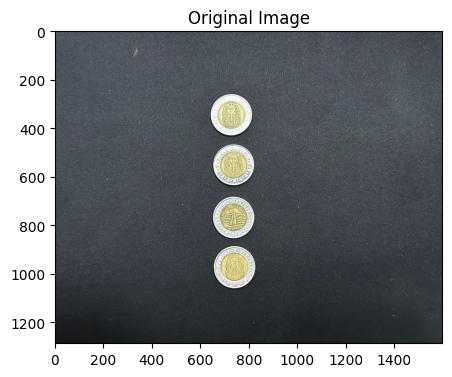

In [240]:
# Enable intellisense
%config IPCompleter.greedy=True

# Image path
imagePath = "/home/adham/Documents/Coin-Counting-System/EGP Coin Dataset/batch1/coin4.jpeg"
# Read image
# Store it in the variable image
###
image = cv2.imread(imagePath)
###
imageCopy = image.copy()
plt.imshow(image[:,:,::-1]);
plt.title("Original Image")



#### GrayScale

In [184]:

# # 1) Grayscale
# imageGray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # 2) Gaussian Blur
# imageBlur = cv2.GaussianBlur(imageGray, (5, 5), 0)

# # 3) Contrast Boost (Histogram Equalization)
# imageContrast = cv2.equalizeHist(imageBlur)

# # Display results
# plt.figure(figsize=(12,5))

# plt.subplot(141)
# plt.imshow(image[:,:,::-1])
# plt.title("Original Image")
# plt.axis("off")

# plt.subplot(142)
# plt.imshow(imageGray, cmap="gray")
# plt.title("Grayscale")
# plt.axis("off")

# plt.subplot(143)
# plt.imshow(imageBlur, cmap="gray")
# plt.title("Gaussian Blur")
# plt.axis("off")

# plt.subplot(144)
# plt.imshow(imageContrast, cmap="gray")
# plt.title("Contrast Boost")
# plt.axis("off")

# plt.show()

### Trials

#### trial 1

In [185]:
# _, imageThresh = cv2.threshold(imageContrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# plt.figure(figsize=(12,12))
# plt.subplot(141)
# plt.imshow(imageThresh, cmap="gray")
# plt.title("Binary (Otsu Threshold)")
# plt.axis("off")
# plt.show()

# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# _,binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# plt.figure(figsize=(12,12))
# plt.subplot(142)
# plt.imshow(binary, cmap="gray")
# plt.title("Binary Image")
# plt.axis("off")
# plt.show()

#### trial 2

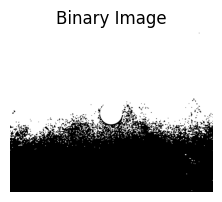

In [186]:
import cv2
import numpy as np

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1) Blur to reduce small noise
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 2) Morphological opening (removes small white noise)
kernel = np.ones((4, 4), np.uint8)
clean = cv2.morphologyEx(blur, cv2.MORPH_OPEN, kernel, iterations=1)

# 3) (optional but strong) closing to smooth coin edges
clean = cv2.morphologyEx(clean, cv2.MORPH_CLOSE, kernel, iterations=1)

# 4) Threshold (binarize)
_, binary = cv2.threshold(clean, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12,12))
plt.subplot(142)
plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

#### trial 3 

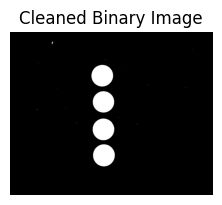

In [241]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((7,7), np.uint8)

# 1) fix internal noise
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# 2) optional: fill object completely
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros_like(clean)
cv2.drawContours(mask, contours, -1, 255, -1)
clean = cv2.bitwise_and(clean, mask)

plt.figure(figsize=(12,12))
plt.subplot(142)
plt.imshow(clean, cmap="gray")
plt.title("Cleaned Binary Image")
plt.axis("off")
plt.show()


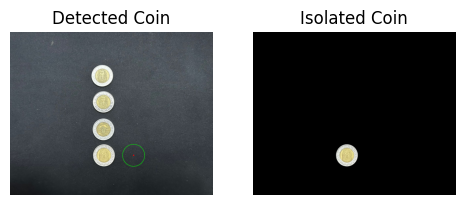

In [242]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5,5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

largest = max(contours, key=cv2.contourArea)

mask = np.zeros_like(clean)
cv2.drawContours(mask, [largest], -1, 255, -1)

coin_only = cv2.bitwise_and(image, image, mask=mask)

(_, _), radius = cv2.minEnclosingCircle(largest)
center = (int(_), int(_))
radius = int(radius)
cv2.circle(imageCopy, center, radius, (0, 255, 0), 2)
cv2.circle(imageCopy, center, 5, (0, 0, 255), -1)      
plt.figure(figsize=(12,12))
plt.subplot(141)
plt.imshow(imageCopy[:,:,::-1])
plt.title("Detected Coin")
plt.axis("off")
plt.subplot(142)
plt.imshow(coin_only[:,:,::-1])
plt.title("Isolated Coin")
plt.axis("off")
plt.show()

Detected coins: 4
Threshold radius: 85.5
Total money: 2.5


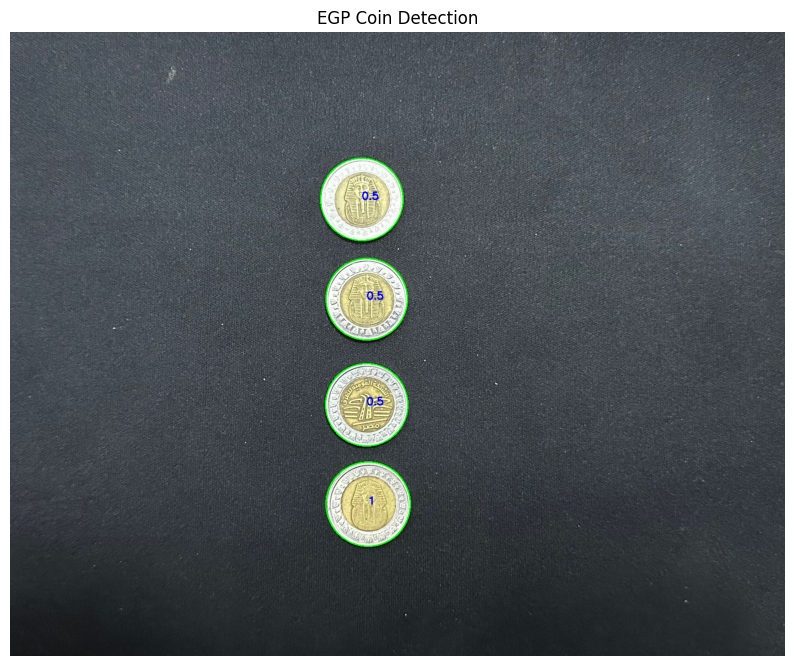

Total money: 2.5
85


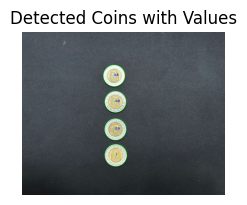

In [243]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imageCopy = image.copy()

# -------------------------
# 1. Preprocessing
# -------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((5, 5), np.uint8)
clean = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)

# -------------------------
# 2. Find contours
# -------------------------
contours, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# -------------------------
# 3. Extract radii
# -------------------------
coins = []  # (radius, center)

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 100:   # remove noise
        continue

    (x, y), radius = cv2.minEnclosingCircle(cnt)
    radius = int(radius)

    coins.append((radius, (int(x), int(y))))

# -------------------------
# 4. Auto threshold (ONLY 2 COINS)
# -------------------------
radii = sorted([c[0] for c in coins])

if len(radii) >= 2:
    threshold = (radii[0] + radii[-1]) / 2
else:
    threshold = 0  # fallback

# -------------------------
# 5. Classification
# -------------------------
def classify_coin(radius, threshold):
    if radius < threshold:
        return 0.5      # small coin
    else:
        return 1    # large coin

total = 0

# -------------------------
# 6. Draw results
# -------------------------
for radius, center in coins:
    value = classify_coin(radius, threshold)
    total += value

    cv2.circle(imageCopy, center, radius, (0, 255, 0), 2)
    cv2.putText(imageCopy, str(value), center,
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

# -------------------------
# 7. Output
# -------------------------
print("Detected coins:", len(coins))
print("Threshold radius:", threshold)
print("Total money:", total)

plt.figure(figsize=(10, 10))
plt.imshow(imageCopy[:, :, ::-1])
plt.title("EGP Coin Detection")
plt.axis("off")
plt.show()

print("Total money:", total)
print(radius)
plt.figure(figsize=(12,12))
plt.subplot(141)
plt.imshow(imageCopy[:,:,::-1])
plt.title("Detected Coins with Values")
plt.axis("off")
plt.show()